# Entrenamiento del modelo

Puesto que el preprocesado y preparación de los datos lo hemos realizado en el *notebook* "dataset_cleaning.ipynb", para el entrenamiento basta con importar los datos. Importamos ambos ficheros, el que contiene los datos de *test* y *train*, y el que contiene los datos de validación.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("../BlackjackData/blackjack_dataset_clean.csv", index_col="Unnamed: 0")
df_val = pd.read_csv("../BlackjackData/blackjack_dataset_clean_validation.csv", index_col="Unnamed: 0")

display(df.head())
df.info()

,cards_remaining,dealer_up,player_hand_value,action,run_count,true_count,carta_1,carta_2,carta_3,carta_4,carta_5,carta_6,carta_7,carta_8,carta_9
0,411,5,17,S,3,0,10,7,0,0,0,0,0,0,0
1,232,5,7,H,2,0,4,3,0,0,0,0,0,0,0
2,208,10,21,S,4,1,2,4,10,5,0,0,0,0,0
3,154,3,19,S,-11,-3,10,9,0,0,0,0,0,0,0
4,343,7,19,S,4,0,3,10,6,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
Index: 6237300 entries, 0 to 6237299
Data columns (total 15 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   cards_remaining    int64 
 1   dealer_up          int64 
 2   player_hand_value  int64 
 3   action             object
 4   run_count          int64 
 5   true_count         int64 
 6   carta_1            int64 
 7   carta_2            int64 
 8   carta_3            int64 
 9   carta_4            int64 
 10  carta_5            int64 
 11  carta_6            int64 
 12  carta_7            int64 
 13  carta_8            int64 
 14  carta_9            int64 
dtypes: int64(14), object(1)
memory usage: 761.4+ MB


Aplicamos un `LabelEncoder` sobre la columna `action` dado que para el tipo de modelo que queremos entrenar no se le pueden pasar variables con `dtype` de tipo `object`.

In [3]:
encoder = LabelEncoder()
df["target_action"] = encoder.fit_transform(df["action"])

Seleccionamos la variable objetivo como la columna que acabamos de crear, con las acciones codificadas, y dejamos el resto de variables para el entrenamiento. Como aclaración, las posibles acciones que se pueden realizar son:
- D: *Double down*, pedir otra carta, doblar la apuesta y finalizar tu turno.
- H: *Hit*, pedir otra carta.
- N: *Insurance*, se ofrece si el crupier tiene un as, permite apostar si el crupier va a tener un blackjack.
- P: *Split*, dividir tu mano en dos, automáticamente añade una carta a cada mano nueva.
- R: *Surrender*, rendirse, se pierde automáticamente.
- S: *Stand*, finaliza tu turno.

In [4]:
X = df.drop(columns=["target_action", "action"])
y = df["target_action"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
model = XGBClassifier(objective="multi:softprob", # Multiclase con probabilidad
                      num_class=len(df["target_action"].unique()),
                      n_estimators=150,
                      learning_rate=0.3,
                      max_depth=6,
                      tree_method="hist",
                      random_state=42,
                      eval_metric="mlogloss")

model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


Al realizar un `classification_report` podemos ver que apenas falla en sus predicciones.

In [6]:
pred = model.predict(X_test)
actions = encoder.classes_

print(classification_report(y_test, pred, target_names=actions))

              precision    recall  f1-score   support

           D       1.00      1.00      1.00     93042
           H       1.00      1.00      1.00    452655
           N       1.00      1.00      1.00     68965
           P       1.00      1.00      1.00     17361
           R       0.99      1.00      1.00     37531
           S       1.00      1.00      1.00    577906

    accuracy                           1.00   1247460
   macro avg       1.00      1.00      1.00   1247460
weighted avg       1.00      1.00      1.00   1247460



Y al comprobar la *accuracy* con los datos de validación, vemos que tiene un valor del 99,97%.

In [ ]:
df_val["target_action"] = encoder.transform(df_val["action"])

X_val = df_val.drop(columns=["target_action", "action"])
y_val = df_val["target_action"]

y_pred_val = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_val)
print(accuracy)

0.9997633590319653


              precision    recall  f1-score   support

           D       1.00      1.00      1.00     51684
           H       1.00      1.00      1.00    251490
           N       1.00      1.00      1.00     38256
           P       1.00      1.00      1.00      9649
           R       0.99      1.00      1.00     20672
           S       1.00      1.00      1.00    321282

    accuracy                           1.00    693033
   macro avg       1.00      1.00      1.00    693033
weighted avg       1.00      1.00      1.00    693033



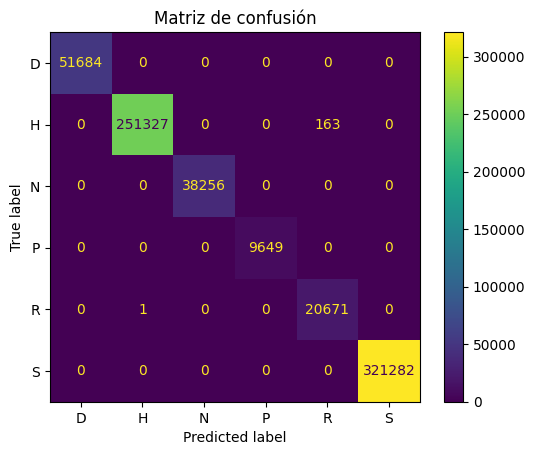

In [15]:
print(classification_report(y_val, y_pred_val, target_names=actions))

cm = confusion_matrix(y_val, y_pred_val, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=actions)
disp.plot()
plt.title("Matriz de confusión")
plt.show()

Para entender mejor el modelo, nos fijamos en que variables tienen más impacto en él. Observamos que se fija en el valor de la mano del jugador y en la carta del crupier, lo cual corresponde con la información en la que se fijaría un jugador real de Blackjack.

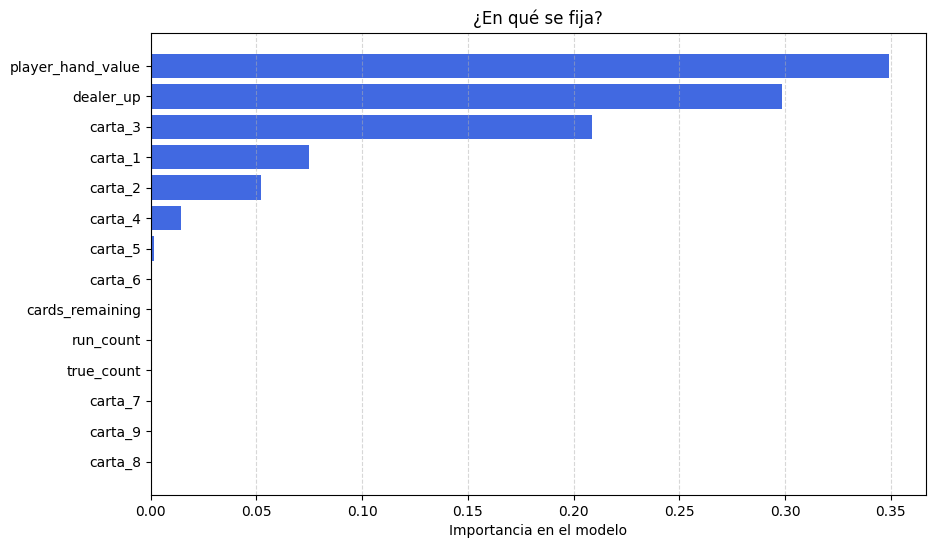

In [16]:
df_importancias = pd.DataFrame(
    {"Columna": X.columns, "Importancia": model.feature_importances_}
).sort_values(by="Importancia", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    df_importancias["Columna"],
    df_importancias["Importancia"],
    color="royalblue",
)
plt.xlabel("Importancia en el modelo")
plt.title("¿En qué se fija?")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

Finalmente, guardamos el modelo para poder ejecutarlo junto con el modelo de *computer vision*.

In [17]:
model.save_model("Models/modelo_blackjack_7M.json")